# SisFall — AFD-CNN Training Notebook

Trains the **AFD-CNN** model from scratch on the SisFall dataset and saves the checkpoint to `model/sisfall_model.ckpt`.

**Input format (repeat-acc variant):** 1200 values = 600 ADXL345 accelerometer values repeated twice.  
The 20×20×3 image the CNN sees has identical top and bottom halves (both encode the accelerometer).

**SisFall activity → class mapping used here:**

| SisFall codes | Class label | Activity |
|---|---|---|
| F01–F15 | 0 | **Fall** |
| D01, D02 | 2 | Walk |
| D03, D04 | 3 | Jog |
| D19 | 4 | Jump |
| D05 | 5 | Up-stairs |
| D06 | 6 | Down-stairs |
| D07, D08 | 7 | Stand→Sit |
| D09, D10 | 9 | Sit→Stand |

**Preprocessing:**
- Downsample 200 Hz → 100 Hz (take every other row)
- Extract 2-second windows (200 samples) with stride 100 (1 s)
- Normalize ADXL345 13-bit ADC values in [−4096, 4095] linearly to [0, 255]
- Cap at 1500 windows per class to keep training manageable
- 80/20 stratified train/test split saved to `data/sisfall_train.csv` and `data/sisfall_test.csv`

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, 'src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
tf.logging.set_verbosity(tf.logging.ERROR)

import importlib, cnn as cnn_module
importlib.reload(cnn_module)

print('TensorFlow version:', tf.__version__)
print('NumPy version:', np.__version__)

I0000 00:00:1776774069.952254    7094 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Instructions for updating:
non-resource variables are not supported in the long term
TensorFlow version: 2.21.0
NumPy version: 2.4.4


## 2. Configuration

In [2]:
SISFALL_PATH   = 'SisFall_dataset'
MODEL_SAVE_PATH = 'model/sisfall_model.ckpt'
TRAIN_CSV      = 'data/sisfall_train.csv'
TEST_CSV       = 'data/sisfall_test.csv'

CLASS_LIST  = [0, 2, 3, 4, 5, 6, 7, 9]
CLASS_NUM   = len(CLASS_LIST)
CLASS_NAMES = {
    0: 'Fall', 2: 'Walk', 3: 'Jog', 4: 'Jump',
    5: 'Up-stairs', 6: 'Down-stairs', 7: 'Stand\u2192Sit', 9: 'Sit\u2192Stand'
}

# SisFall activity code → class label
CODE_TO_LABEL = {
    **{f'F{i:02d}': 0 for i in range(1, 16)},  # F01-F15 → Fall
    'D01': 2, 'D02': 2,   # Walk
    'D03': 3, 'D04': 3,   # Jog
    'D19': 4,             # Jump
    'D05': 5,             # Up/down-stairs slow  → Up-stairs
    'D06': 6,             # Up/down-stairs quick → Down-stairs
    'D07': 7, 'D08': 7,  # Half-height chair sit+stand  → Stand→Sit
    'D09': 9, 'D10': 9,  # Low-height chair sit+stand   → Sit→Stand
}

WINDOW        = 200   # samples per window at 100 Hz = 2 s
STRIDE        = 100   # stride in samples (1 s)
MAX_PER_CLASS = 1500  # cap to keep training manageable

print('Classes:', CLASS_LIST)
print('Activity codes tracked:', sorted(CODE_TO_LABEL.keys()))

Classes: [0, 2, 3, 4, 5, 6, 7, 9]
Activity codes tracked: ['D01', 'D02', 'D03', 'D04', 'D05', 'D06', 'D07', 'D08', 'D09', 'D10', 'D19', 'F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15']


## 3. Parse SisFall and Extract Windows

Each `.txt` file has 9 columns at 200 Hz:
- Cols 0–2: **ADXL345** accelerometer (13-bit, ±16 g) — *used here*
- Cols 3–5: ITG-3200 gyroscope
- Cols 6–8: MMA8451Q accelerometer

We downsample to 100 Hz and normalize the ADXL345 values to [0, 255].

In [3]:
def parse_sisfall_txt(filepath):
    """Read a SisFall .txt file → float32 array (N, 9) of raw ADC values."""
    rows = []
    with open(filepath) as f:
        for line in f:
            line = line.strip().rstrip(';')
            if not line:
                continue
            try:
                parts = [int(x.strip()) for x in line.split(',')]
                if len(parts) == 9:
                    rows.append(parts)
            except ValueError:
                pass
    return np.array(rows, dtype=np.float32) if rows else None


def normalize_adxl345(raw):
    """Map ADXL345 13-bit ADC values in [-4096, 4095] linearly to [0, 255]."""
    return np.clip((raw + 4096.0) / 8192.0 * 255.0, 0.0, 255.0)


def extract_windows(arr, window=200, stride=100):
    """Slide a window over (T, 3) time-series → list of (window, 3) arrays."""
    n = len(arr)
    return [arr[s:s + window] for s in range(0, n - window + 1, stride)]


print('Helper functions defined.')

Helper functions defined.


In [4]:
np.random.seed(42)

X_acc_list = []   # each entry: (600,) float32 — normalized ADXL345
y_list     = []   # integer class labels
counts     = {l: 0 for l in CLASS_LIST}

skip_prefixes = {'desktop', 'Links', 'Readme'}

for subj in sorted(os.listdir(SISFALL_PATH)):
    subj_path = os.path.join(SISFALL_PATH, subj)
    if not os.path.isdir(subj_path):
        continue

    for fname in sorted(os.listdir(subj_path)):
        if not fname.endswith('.txt'):
            continue
        if any(fname.startswith(p) for p in skip_prefixes):
            continue

        code = fname.split('_')[0]
        if code not in CODE_TO_LABEL:
            continue

        label = CODE_TO_LABEL[code]
        if counts[label] >= MAX_PER_CLASS:
            continue

        raw = parse_sisfall_txt(os.path.join(subj_path, fname))
        if raw is None or len(raw) < WINDOW * 2:   # need at least WINDOW rows after downsample
            continue

        # Downsample 200 Hz → 100 Hz
        raw_ds = raw[::2]                          # (T/2, 9)

        # ADXL345: columns 0, 1, 2
        acc = normalize_adxl345(raw_ds[:, 0:3])    # (T/2, 3), values in [0, 255]

        windows = extract_windows(acc, window=WINDOW, stride=STRIDE)
        np.random.shuffle(windows)                 # shuffle within file for variety

        for win in windows:
            if counts[label] >= MAX_PER_CLASS:
                break
            X_acc_list.append(win.flatten().astype(np.float32))   # (600,)
            y_list.append(label)
            counts[label] += 1

X_acc = np.array(X_acc_list, dtype=np.float32)   # (N, 600)
y     = np.array(y_list, dtype=int)

print(f'Total windows: {len(X_acc)}')
print(f'Sensor value range: [{X_acc.min():.1f}, {X_acc.max():.1f}]')
print()
print(f'{"Class":>12s}  {"Count":>7}')
print('-' * 22)
for lbl in CLASS_LIST:
    print(f'{CLASS_NAMES[lbl]:>12s}  {(y == lbl).sum():>7}')

Total windows: 11820
Sensor value range: [1.7, 220.1]

       Class    Count
----------------------
        Fall     1500
        Walk     1500
         Jog     1500
        Jump     1320
   Up-stairs     1500
 Down-stairs     1500
   Stand→Sit     1500
   Sit→Stand     1500


## 4. Visualise Sample Windows

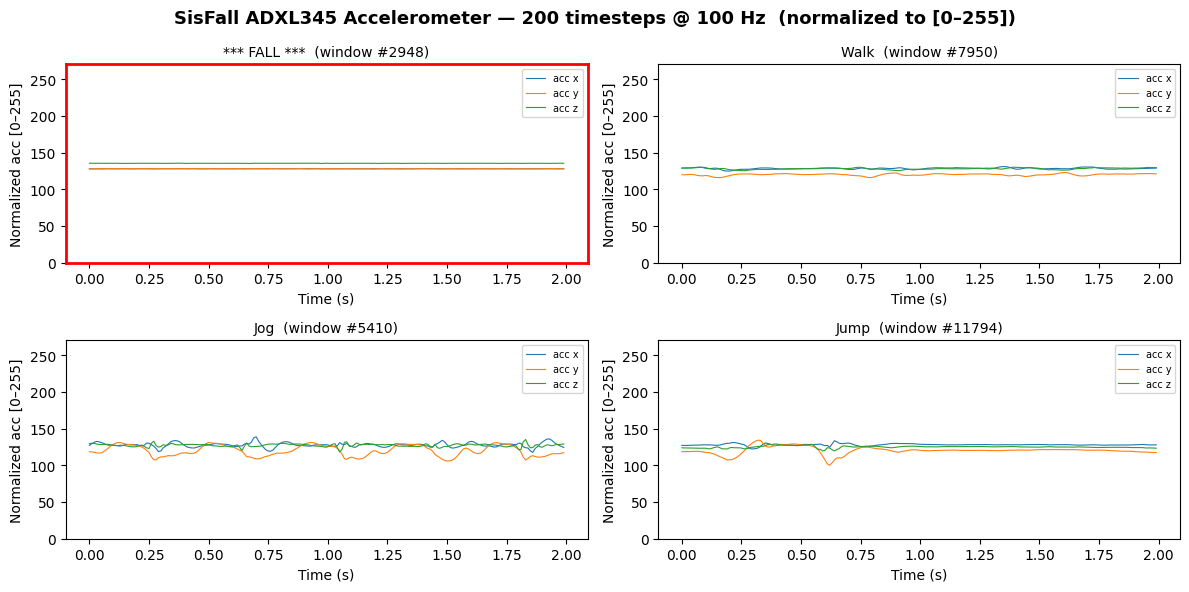

In [5]:
np.random.seed(42)
show_labels = [0, 2, 3, 4]   # Fall, Walk, Jog, Jump

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green']

for ax, label in zip(axes.flat, show_labels):
    idxs = np.where(y == label)[0]
    sample_i = idxs[np.random.randint(len(idxs))]
    acc_data = X_acc[sample_i].reshape(200, 3)   # (200 timesteps, 3 axes)
    t = np.arange(200) / 100.0                    # time axis in seconds

    for i, (axis_name, color) in enumerate(zip(['x', 'y', 'z'], colors)):
        ax.plot(t, acc_data[:, i], color=color, linewidth=0.8, label=f'acc {axis_name}')

    tag = '*** FALL ***' if label == 0 else CLASS_NAMES[label]
    ax.set_title(f'{tag}  (window #{sample_i})', fontsize=10)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Normalized acc [0\u2013255]')
    ax.legend(fontsize=7)
    ax.set_ylim(0, 270)

    if label == 0:
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(2)

fig.suptitle('SisFall ADXL345 Accelerometer — 200 timesteps @ 100 Hz  (normalized to [0\u2013255])',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

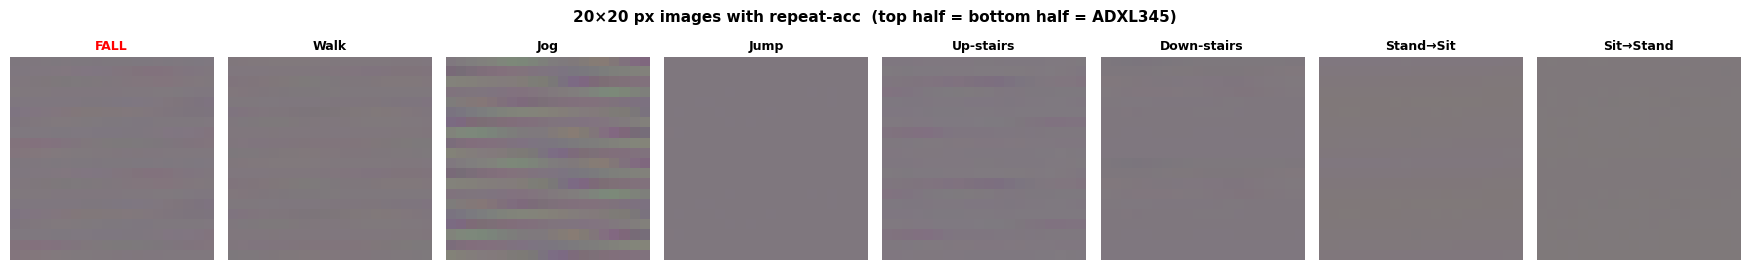

In [6]:
def to_image_repeat(acc_flat):
    """Repeat-acc: copy acc (600 values) to both halves → 20×20×3 image in [0, 1] for display."""
    repeated = np.concatenate([acc_flat, acc_flat])   # (1200,)
    return repeated.reshape(20, 20, 3) / 255.0


np.random.seed(7)
n = len(CLASS_LIST)

fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 2.8))
for ax, label in zip(axes, CLASS_LIST):
    idxs = np.where(y == label)[0]
    sample_i = idxs[np.random.randint(len(idxs))]
    img = to_image_repeat(X_acc[sample_i])
    ax.imshow(img)
    tag = 'FALL' if label == 0 else CLASS_NAMES[label]
    ax.set_title(tag, fontsize=9, color='red' if label == 0 else 'black', fontweight='bold')
    ax.axis('off')

fig.suptitle('20\u00d720 px images with repeat-acc  (top half = bottom half = ADXL345)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Train / Test Split and Save CSVs

Stratified 80/20 split.  
CSVs store the raw 600 acc values — the repeat is applied at inference time.

In [7]:
idx_train, idx_test = train_test_split(
    np.arange(len(X_acc)), test_size=0.2, random_state=42, stratify=y
)

X_acc_train, X_acc_test = X_acc[idx_train], X_acc[idx_test]
y_train,     y_test     = y[idx_train],     y[idx_test]

print(f'Train: {len(X_acc_train)} samples | Test: {len(X_acc_test)} samples')
print()
print(f'{"Class":>12s}  {"Train":>7}  {"Test":>6}')
print('-' * 32)
for lbl in CLASS_LIST:
    print(f'{CLASS_NAMES[lbl]:>12s}  {(y_train == lbl).sum():>7}  {(y_test == lbl).sum():>6}')

Train: 9456 samples | Test: 2364 samples

       Class    Train    Test
--------------------------------
        Fall     1200     300
        Walk     1200     300
         Jog     1200     300
        Jump     1056     264
   Up-stairs     1200     300
 Down-stairs     1200     300
   Stand→Sit     1200     300
   Sit→Stand     1200     300


In [8]:
col_names = ['label'] + [str(i + 1) for i in range(600)]

train_df = pd.DataFrame(
    np.column_stack([y_train.astype(float), X_acc_train]),
    columns=col_names
)
train_df['label'] = y_train
train_df.to_csv(TRAIN_CSV, index=False)

test_df = pd.DataFrame(
    np.column_stack([y_test.astype(float), X_acc_test]),
    columns=col_names
)
test_df['label'] = y_test
test_df.to_csv(TEST_CSV, index=False)

print(f'Saved  {TRAIN_CSV}  ({len(train_df)} rows, 600 acc values each)')
print(f'Saved  {TEST_CSV}   ({len(test_df)} rows, 600 acc values each)')

Saved  data/sisfall_train.csv  (9456 rows, 600 acc values each)
Saved  data/sisfall_test.csv   (2364 rows, 600 acc values each)


## 6. Build Model Inputs (Apply Repeat-Acc)

The model expects 1200 values.  
Repeat-acc: `[acc_600, acc_600]` — both halves are identical.

In [9]:
def apply_repeat_acc(X_600):
    """Expand (N, 600) acc array to (N, 1200) by repeating the acc half."""
    return np.hstack([X_600, X_600]).astype(np.float32)


def to_onehot(labels_arr, class_list):
    y_oh = np.zeros((len(labels_arr), len(class_list)), dtype=np.float32)
    for i, lbl in enumerate(labels_arr):
        y_oh[i, class_list.index(lbl)] = 1.0
    return y_oh


X_model_train = apply_repeat_acc(X_acc_train)   # (N_train, 1200)
X_model_test  = apply_repeat_acc(X_acc_test)    # (N_test,  1200)
y_train_oh    = to_onehot(y_train, CLASS_LIST)
y_test_oh     = to_onehot(y_test,  CLASS_LIST)

print(f'Model input shapes — train: {X_model_train.shape}, test: {X_model_test.shape}')
print(f'Value range in model input: [{X_model_train.min():.1f}, {X_model_train.max():.1f}]')

Model input shapes — train: (9456, 1200), test: (2364, 1200)
Value range in model input: [1.7, 220.1]


## 7. Build TF Graph and Train

In [10]:
TRAIN_STEPS   = 5000
BATCH_SIZE    = 50
LEARNING_RATE = 0.001

tf.reset_default_graph()

x_ph = tf.placeholder(tf.float32, [None, 1200], name='input')
y_ph = tf.placeholder(tf.float32, [None, CLASS_NUM], name='labels')

logits, keep_prob_ph = cnn_module.fall_net(x_ph)

loss_op = tf.reduce_mean(
    tf.nn.softmax_cross_entropy_with_logits(labels=y_ph, logits=logits)
)
train_op = tf.train.AdamOptimizer(LEARNING_RATE).minimize(loss_op)
correct_op = tf.equal(tf.argmax(logits, 1), tf.argmax(y_ph, 1))
acc_op = tf.reduce_mean(tf.cast(correct_op, tf.float32))
probs_op = tf.nn.softmax(logits)

saver = tf.train.Saver()
sess  = tf.Session()
sess.run(tf.global_variables_initializer())

print(f'Graph built.  Training on {len(X_model_train)} samples for {TRAIN_STEPS} steps...')

Graph built.  Training on 9456 samples for 5000 steps...


E0000 00:00:1776774089.372199    7094 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1776774089.379724    7094 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


In [11]:
n_train = len(X_model_train)
perm = np.random.permutation(n_train)
ptr  = 0

log_steps, log_loss, log_acc = [], [], []

for step in range(1, TRAIN_STEPS + 1):
    if ptr + BATCH_SIZE > n_train:
        perm = np.random.permutation(n_train)
        ptr  = 0

    batch_idx = perm[ptr:ptr + BATCH_SIZE]
    ptr += BATCH_SIZE

    feed = {x_ph: X_model_train[batch_idx],
            y_ph: y_train_oh[batch_idx],
            keep_prob_ph: 0.5}
    _, loss_val = sess.run([train_op, loss_op], feed_dict=feed)

    if step % 500 == 0:
        acc_val = acc_op.eval(session=sess,
                              feed_dict={x_ph: X_model_train[batch_idx],
                                         y_ph: y_train_oh[batch_idx],
                                         keep_prob_ph: 1.0})
        log_steps.append(step)
        log_loss.append(loss_val)
        log_acc.append(acc_val)
        print(f'Step {step:5d}  |  loss = {loss_val:.4f}  |  batch acc = {acc_val:.4f}')

save_path = saver.save(sess, MODEL_SAVE_PATH)
print(f'\nModel saved to {save_path}')

Step   500  |  loss = 0.9538  |  batch acc = 0.6400
Step  1000  |  loss = 0.8277  |  batch acc = 0.6400
Step  1500  |  loss = 0.4588  |  batch acc = 0.8200
Step  2000  |  loss = 0.6700  |  batch acc = 0.6800
Step  2500  |  loss = 0.5286  |  batch acc = 0.7800
Step  3000  |  loss = 0.3854  |  batch acc = 0.8200
Step  3500  |  loss = 0.4442  |  batch acc = 0.8200
Step  4000  |  loss = 0.4436  |  batch acc = 0.7600
Step  4500  |  loss = 0.2357  |  batch acc = 0.9000
Step  5000  |  loss = 0.4241  |  batch acc = 0.9000

Model saved to model/sisfall_model.ckpt


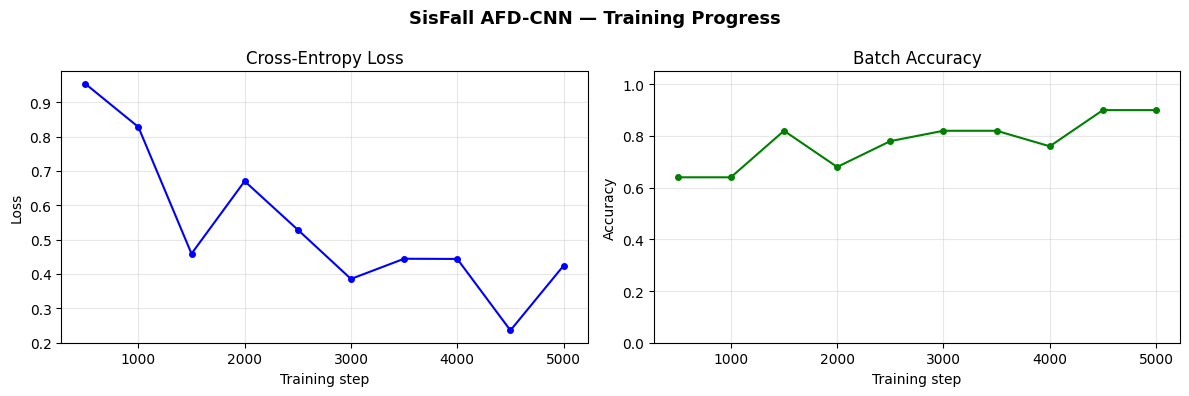

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(log_steps, log_loss, 'b-o', markersize=4)
ax1.set_title('Cross-Entropy Loss')
ax1.set_xlabel('Training step')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(log_steps, log_acc, 'g-o', markersize=4)
ax2.set_title('Batch Accuracy')
ax2.set_xlabel('Training step')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)

fig.suptitle('SisFall AFD-CNN — Training Progress', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Evaluate on Train and Test Sets

In [13]:
def run_inference(X):
    """Run model on (N, 1200) array in batches; return pred_labels (N,) and probs (N, 8)."""
    EVAL_BATCH = 256
    all_probs = []
    for start in range(0, len(X), EVAL_BATCH):
        p = sess.run(probs_op, feed_dict={x_ph: X[start:start + EVAL_BATCH], keep_prob_ph: 1.0})
        all_probs.append(p)
    all_probs = np.vstack(all_probs)
    pred_idx    = np.argmax(all_probs, axis=1)
    pred_labels = np.array([CLASS_LIST[i] for i in pred_idx])
    return pred_labels, all_probs


for split_name, X_split, y_split in [
        ('Train', X_model_train, y_train),
        ('Test',  X_model_test,  y_test)]:

    pred_labels, _ = run_inference(X_split)
    overall = np.mean(pred_labels == y_split)

    print(f'=== {split_name} set ({len(y_split)} samples) ===')
    print(f'Overall accuracy: {overall:.4f}  ({overall:.2%})')
    print(f'{"Class":>12s}  {"N":>5}  {"Sensitivity":>12}  {"Specificity":>12}')
    print('-' * 48)

    for lbl in CLASS_LIST:
        acc, sens, spec = cnn_module.evaluate(pred_labels, y_split, lbl)
        n_cls = int((y_split == lbl).sum())
        print(f'{CLASS_NAMES[lbl]:>12s}  {n_cls:>5}  {sens:>12.4f}  {spec:>12.4f}')
    print()

=== Train set (9456 samples) ===
Overall accuracy: 0.8374  (83.74%)
       Class      N   Sensitivity   Specificity
------------------------------------------------
        Fall   1200        0.9700        0.9896
        Walk   1200        0.9975        0.9999
         Jog   1200        0.9992        1.0000
        Jump   1056        0.6515        0.9937
   Up-stairs   1200        0.9100        0.9969
 Down-stairs   1200        0.8442        0.9290
   Stand→Sit   1200        0.7183        0.9347
   Sit→Stand   1200        0.5858        0.9701

=== Test set (2364 samples) ===
Overall accuracy: 0.7965  (79.65%)
       Class      N   Sensitivity   Specificity
------------------------------------------------
        Fall    300        0.9233        0.9797
        Walk    300        0.9700        0.9952
         Jog    300        0.9833        0.9976
        Jump    264        0.6439        0.9895
   Up-stairs    300        0.8600        0.9947
 Down-stairs    300        0.7867        0.929

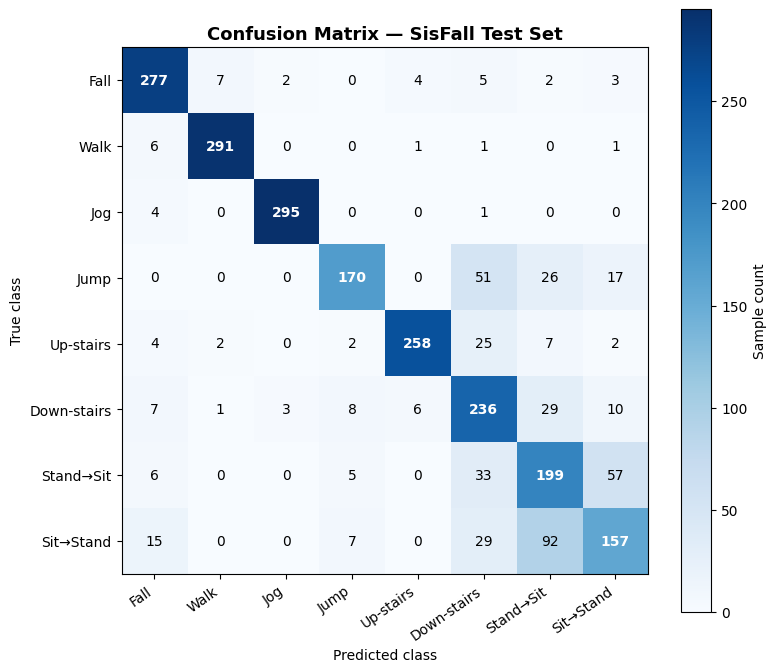

Training complete. Session closed.
Checkpoint saved at: model/sisfall_model.ckpt
Test CSV saved at:   data/sisfall_test.csv


In [14]:
pred_test, _ = run_inference(X_model_test)
label_names  = [CLASS_NAMES[l] for l in CLASS_LIST]
cm = confusion_matrix(y_test, pred_test, labels=CLASS_LIST)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax, label='Sample count')

ax.set_xticks(range(len(CLASS_LIST)))
ax.set_yticks(range(len(CLASS_LIST)))
ax.set_xticklabels(label_names, rotation=35, ha='right')
ax.set_yticklabels(label_names)
ax.set_xlabel('Predicted class')
ax.set_ylabel('True class')
ax.set_title('Confusion Matrix \u2014 SisFall Test Set', fontsize=13, fontweight='bold')

for i in range(len(CLASS_LIST)):
    for j in range(len(CLASS_LIST)):
        val    = cm[i, j]
        color  = 'white' if val > cm.max() / 2 else 'black'
        weight = 'bold' if i == j else 'normal'
        ax.text(j, i, str(val), ha='center', va='center',
                fontsize=10, color=color, fontweight=weight)

plt.tight_layout()
plt.show()

sess.close()
print('Training complete. Session closed.')
print(f'Checkpoint saved at: {MODEL_SAVE_PATH}')
print(f'Test CSV saved at:   {TEST_CSV}')